In [ ]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
df=pd.read_csv("/content/4th dataset morgan.csv")

**Task 5**: Visualisation

 Conduct extensive exploratory data analysis with attractive visualizations for your
findings

In [ ]:
#1. Dataset Overview
print(df.shape)

(800, 26)


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   TransactionID        800 non-null    int64  
 1   CustomerID           800 non-null    object 
 2   AccountID            800 non-null    object 
 3   AccountType          800 non-null    object 
 4   TransactionType      800 non-null    object 
 5   Product              800 non-null    object 
 6   Firm                 800 non-null    object 
 7   Region               800 non-null    object 
 8   Manager              800 non-null    object 
 9   TransactionDate      800 non-null    object 
 10  TransactionAmount    800 non-null    float64
 11  AccountBalance       800 non-null    float64
 12  RiskScore            800 non-null    float64
 13  CreditRating         800 non-null    int64  
 14  TenureMonths         800 non-null    int64  
 15  Year                 800 non-null    int

In [ ]:
print(df.describe())

       TransactionID  TransactionAmount  AccountBalance   RiskScore  \
count     800.000000         800.000000      800.000000  800.000000   
mean       99.786250       55194.889273    72764.355699    0.473380   
std        57.460793       28940.337792    35623.574024    0.239982   
min         1.000000      -36173.695550   -62548.722060   -0.300118   
25%        50.000000       34842.164247    48684.199043    0.312271   
50%        99.500000       53768.493325    72908.053070    0.485829   
75%       150.000000       74729.551358    95574.572673    0.632799   
max       199.000000      154662.045800   180539.287700    1.254704   

       CreditRating  TenureMonths         Year      NetAmount     GapDays  \
count    800.000000    800.000000   800.000000     800.000000  611.000000   
mean     568.526250    119.870000  2023.291250  -27752.770414   92.512275   
std      155.620111     67.356806     0.454623   55826.978902   85.336716   
min      306.000000      6.000000  2023.000000 -1546

In [ ]:
#Missing Values
print(df.isnull().sum())

TransactionID            0
CustomerID               0
AccountID                0
AccountType              0
TransactionType          0
Product                  0
Firm                     0
Region                   0
Manager                  0
TransactionDate          0
TransactionAmount        0
AccountBalance           0
RiskScore                0
CreditRating             0
TenureMonths             0
Year                     0
Month                    0
NetAmount                0
PreviousTransaction    189
GapDays                189
Status                   0
AverageBalance           0
TransactionVolume        0
CustomerSegment          0
ZScore                   0
SuspiciousStatus         0
dtype: int64


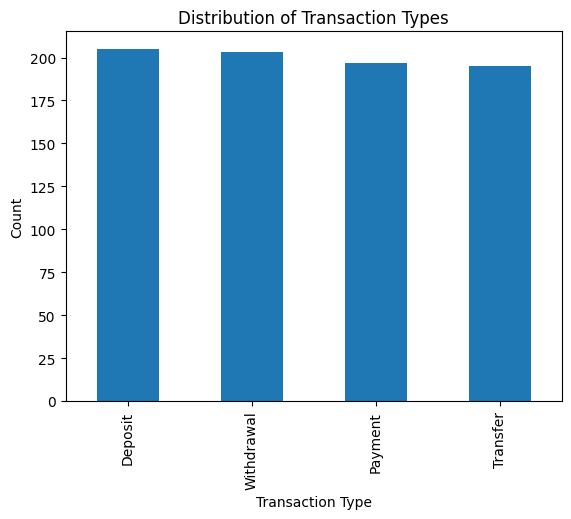

In [ ]:
#Transaction Type Distribution
transaction_count = df["TransactionType"].value_counts()

transaction_count.plot(kind="bar")

plt.title("Distribution of Transaction Types")
plt.xlabel("Transaction Type")
plt.ylabel("Count")

plt.show()

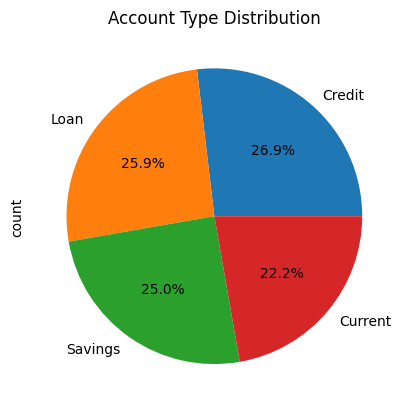

In [ ]:
#Account Type Distribution
account_type = df["AccountType"].value_counts()

account_type.plot(kind="pie", autopct="%1.1f%%")

plt.title("Account Type Distribution")

plt.show()

In [ ]:
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])

In [ ]:
df["NetAmount"] = 0

df.loc[df["TransactionType"] == "Deposit", "NetAmount"] = df["TransactionAmount"]

df.loc[df["TransactionType"].isin(["Withdrawal", "Payment"]), "NetAmount"] = -df["TransactionAmount"]

/tmp/ipykernel_1589/1913342198.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 52336.34278    57555.96513    80583.87766   116828.2616
  73780.24903    65676.37299     3795.970129    5380.233028
  43879.60844    43322.41625    78950.07454    69537.34668
  30024.48834    71686.40065    27823.77274    35537.16106
  31823.48187    30451.57674     7531.594658   45419.60309
  68223.01432    21245.47279    39472.17958    62859.6279
  77499.73006    45648.16907    80243.42155    55877.7992
  69626.63321    50026.65173     5842.519929   24026.76247
  41145.93667    16579.28117    45229.26892    23372.02063
  33128.6774     36846.93775    74244.98012    79371.22735
  64407.6291     38910.22395    19802.05077    16937.67889
  19628.34838    22125.71278    84074.76953    18812.19933
  -1756.162758   82726.93757    32949.06778    40017.19677
  84564.39895    66372.85081    38092.49854    60705.8527
  34882.503

In [ ]:
net_inflow = df.groupby("AccountID")["NetAmount"].sum().reset_index(name="NetInflow")

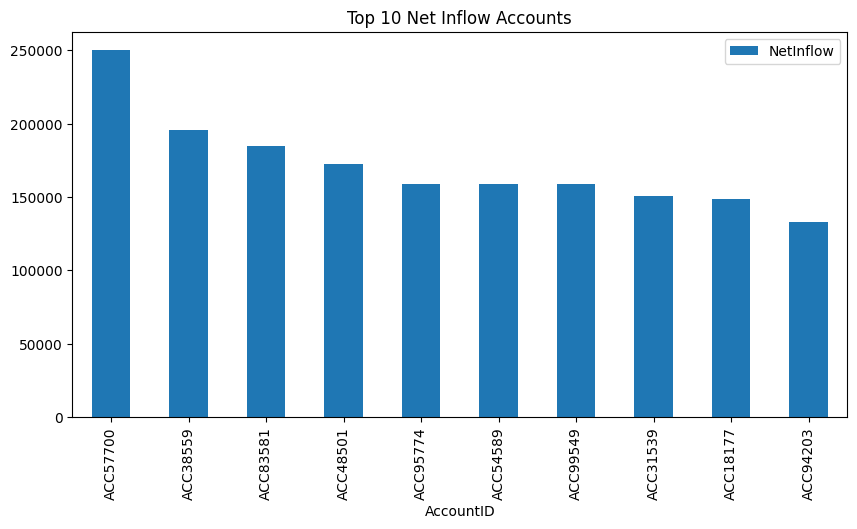

In [ ]:
#Top 10 Net Inflow Accounts
top_accounts = net_inflow.sort_values(by="NetInflow", ascending=False).head(10)

top_accounts.plot(
    x="AccountID",
    y="NetInflow",
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Net Inflow Accounts")
plt.show()

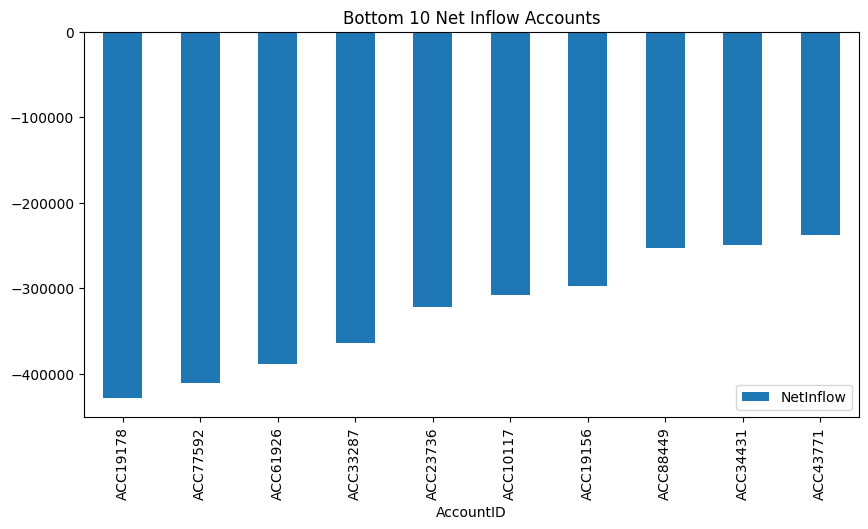

In [ ]:
#Bottom 10 Net Inflow Accounts
bottom_accounts = net_inflow.sort_values(by="NetInflow").head(10)

bottom_accounts.plot(
    x="AccountID",
    y="NetInflow",
    kind="bar",
    figsize=(10,5)
)

plt.title("Bottom 10 Net Inflow Accounts")
plt.show()

In [ ]:
account_activity = df.groupby("AccountID").size().reset_index(name="TransactionCount")

In [ ]:
def activity_level(count):
    if count >= 6:
        return "High"
    elif count >= 3:
        return "Medium"
    else:
        return "Low"

account_activity["ActivityLevel"] = account_activity["TransactionCount"].apply(activity_level)

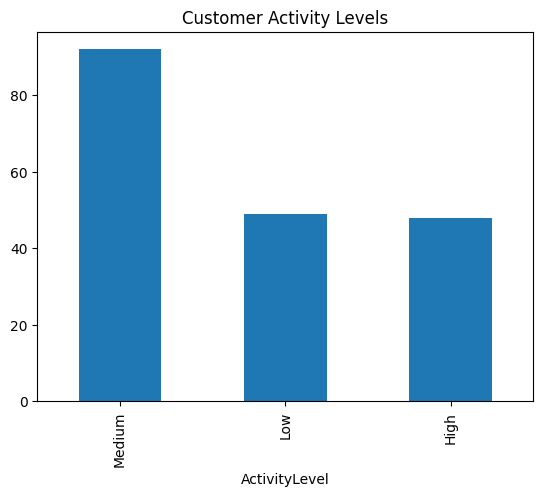

In [ ]:
#Activity Levels
account_activity["ActivityLevel"].value_counts().plot(kind="bar")

plt.title("Customer Activity Levels")
plt.show()

In [ ]:
#Customer Segments
df["AverageBalance"] = df.groupby("AccountID")["AccountBalance"].transform("mean")

transaction_volume = df.groupby("AccountID").size().reset_index(name="TransactionVolume")

df = df.merge(transaction_volume, on="AccountID", how="left")

In [ ]:
def customer_segment(row):
    if row["AverageBalance"] >= 81819 and row["TransactionVolume"] >= 6:
        return "Premium"
    elif row["AverageBalance"] >= 64075 and row["TransactionVolume"] >= 3:
        return "Regular"
    else:
        return "Basic"

df["CustomerSegment"] = df.apply(customer_segment, axis=1)

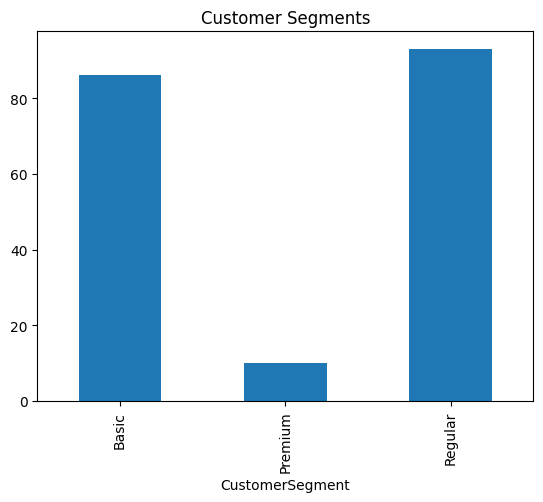

In [ ]:
segment = df.groupby("CustomerSegment")["AccountID"].nunique()

segment.plot(kind="bar")

plt.title("Customer Segments")
plt.show()

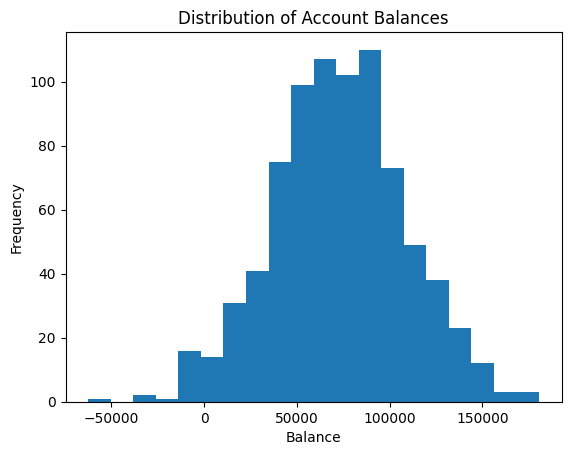

In [ ]:
#Balance Distribution
plt.hist(df["AccountBalance"], bins=20)

plt.title("Distribution of Account Balances")
plt.xlabel("Balance")
plt.ylabel("Frequency")

plt.show()

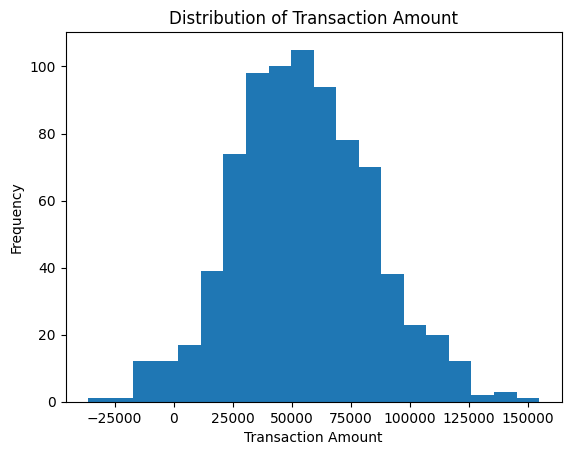

In [ ]:
#Transaction Amount Distribution
plt.hist(df["TransactionAmount"], bins=20)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

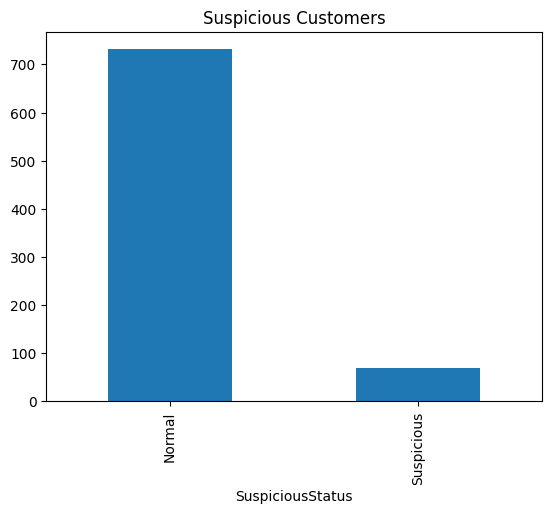

In [ ]:
#Suspicious Customers
df["SuspiciousStatus"].value_counts().plot(kind="bar")

plt.title("Suspicious Customers")

plt.show()

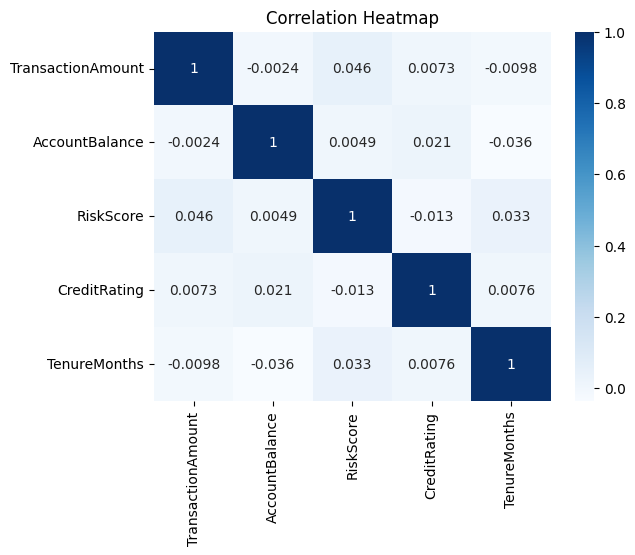

In [ ]:
#Correlation Heatmap
import seaborn as sns

corr = df[[
    "TransactionAmount",
    "AccountBalance",
    "RiskScore",
    "CreditRating",
    "TenureMonths"
]].corr()

sns.heatmap(corr,
            annot=True,
            cmap="Blues")

plt.title("Correlation Heatmap")

plt.show()

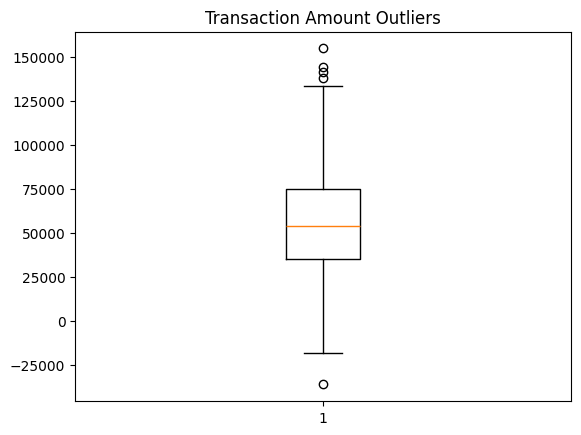

In [ ]:
#Boxplot for Outliers
plt.boxplot(df["TransactionAmount"])

plt.title("Transaction Amount Outliers")

plt.show()

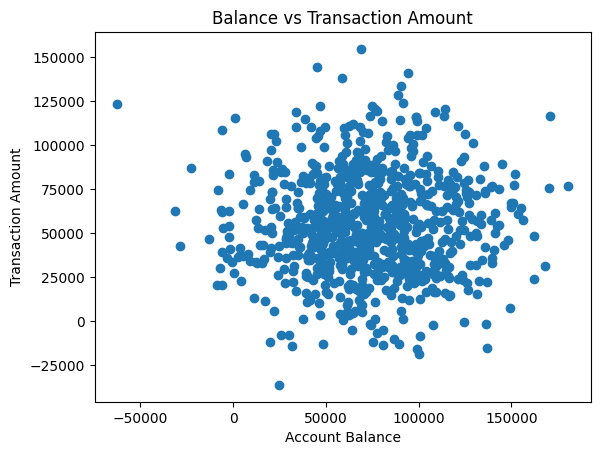

In [ ]:
#Scatter Plot
plt.scatter(df["AccountBalance"],
            df["TransactionAmount"])

plt.xlabel("Account Balance")
plt.ylabel("Transaction Amount")

plt.title("Balance vs Transaction Amount")

plt.show()

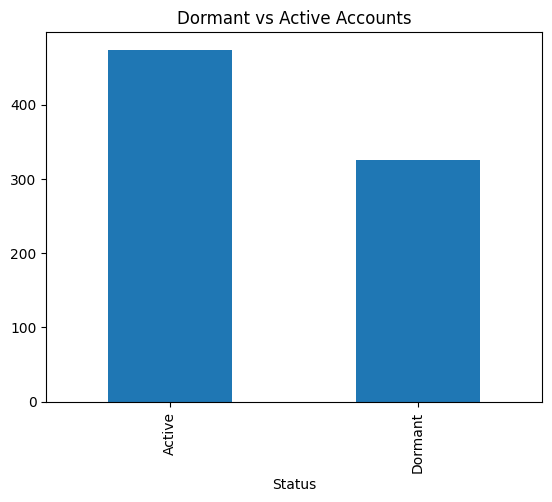

In [ ]:
#Dormant vs Active Accounts
df["Status"].value_counts().plot(kind="bar")

plt.title("Dormant vs Active Accounts")

plt.show()